In [109]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [110]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import PowerTransformer

In [111]:
df = pd.read_csv('concrete_data.csv')

In [112]:
df.head()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


In [113]:
df.shape

(1030, 9)

In [114]:
df.isnull().sum()

Cement                0
Blast Furnace Slag    0
Fly Ash               0
Water                 0
Superplasticizer      0
Coarse Aggregate      0
Fine Aggregate        0
Age                   0
Strength              0
dtype: int64

In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Cement              1030 non-null   float64
 1   Blast Furnace Slag  1030 non-null   float64
 2   Fly Ash             1030 non-null   float64
 3   Water               1030 non-null   float64
 4   Superplasticizer    1030 non-null   float64
 5   Coarse Aggregate    1030 non-null   float64
 6   Fine Aggregate      1030 non-null   float64
 7   Age                 1030 non-null   int64  
 8   Strength            1030 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 72.6 KB


In [116]:
df.describe()

,Cement,Blast Furnace Slag,Fly Ash,Water,Superplasticizer,Coarse Aggregate,Fine Aggregate,Age,Strength
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [117]:
X = df.drop(columns=['Strength'])
y = df.iloc[:,-1]

In [118]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2,
                                                   random_state=42)

In [119]:
#Applying Linear Regression without transformation
lr = LinearRegression()

lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
r2_score(y_test, y_pred)

0.627553179231485

In [120]:
#Cross checking with cross_val_score()
lr = LinearRegression()
np.mean(cross_val_score(lr,X,y,scoring='r2'))

np.float64(0.46099404916628667)

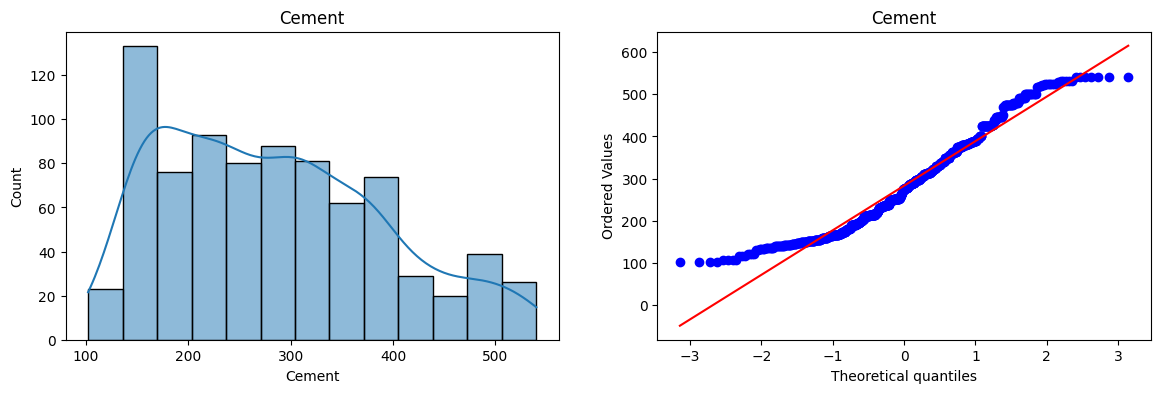

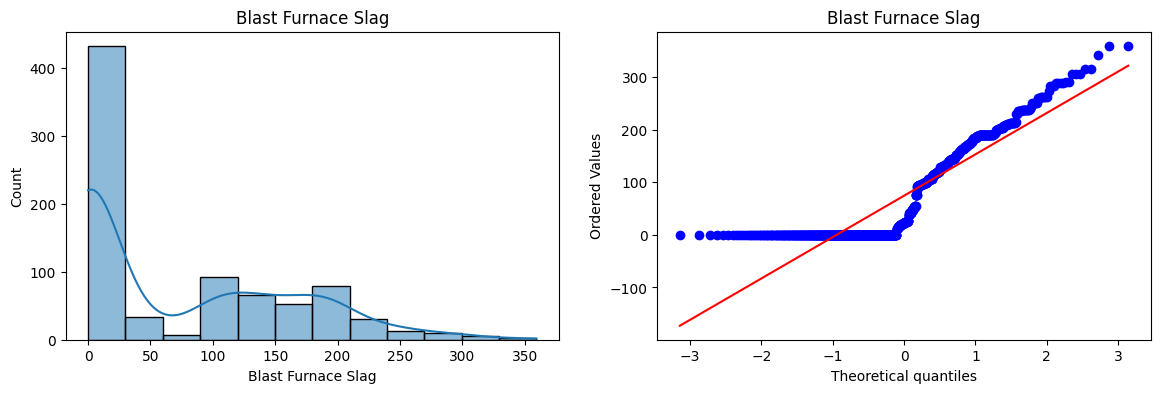

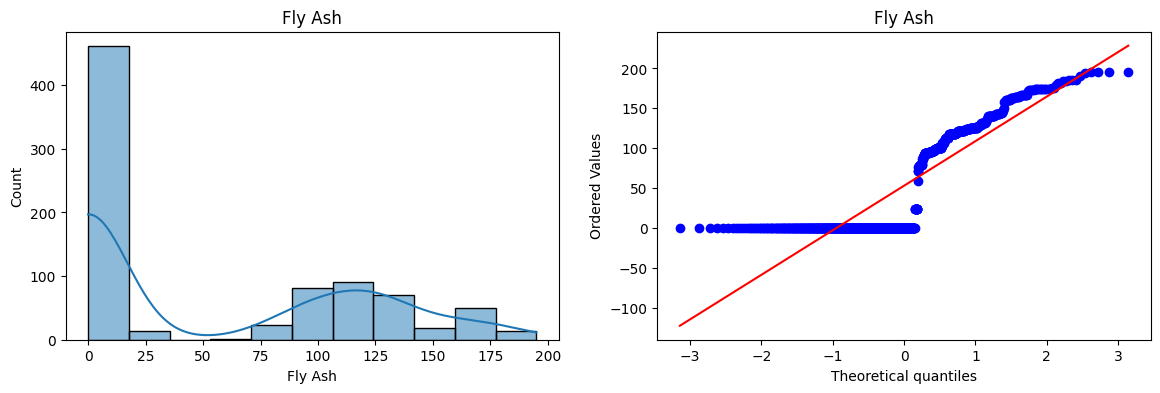

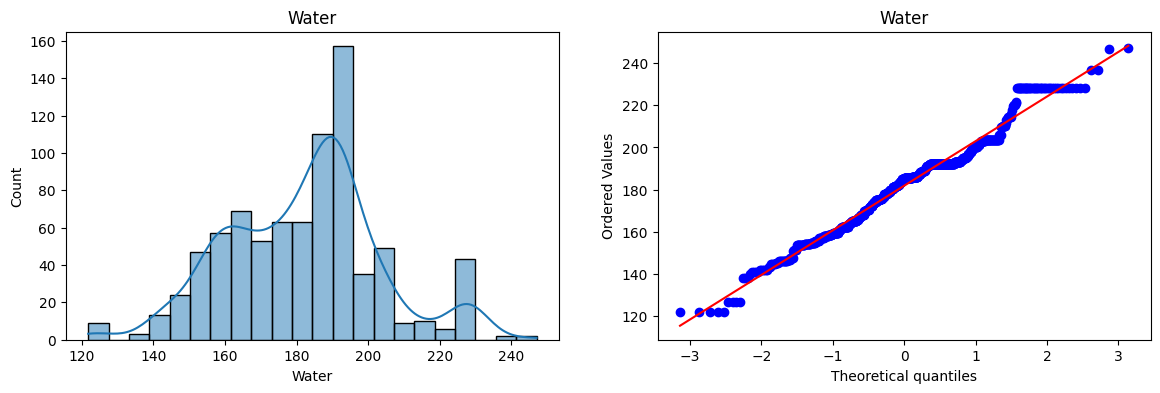

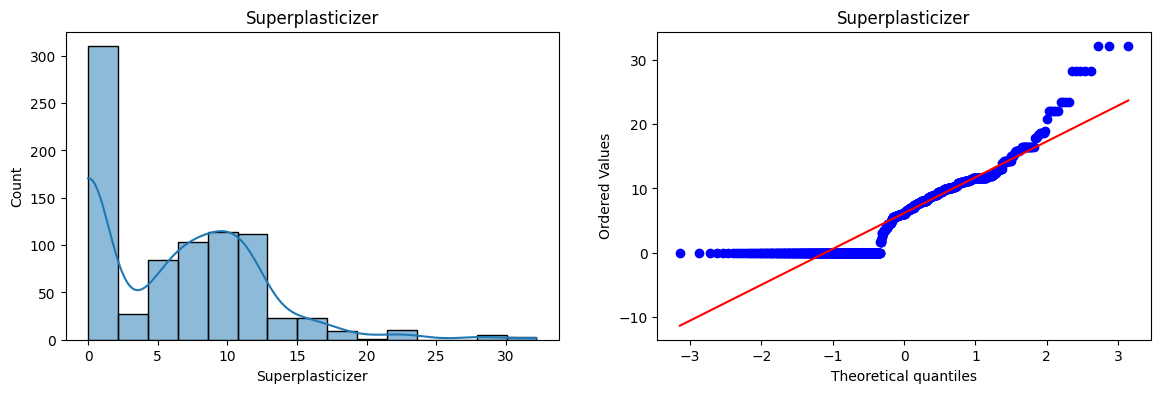

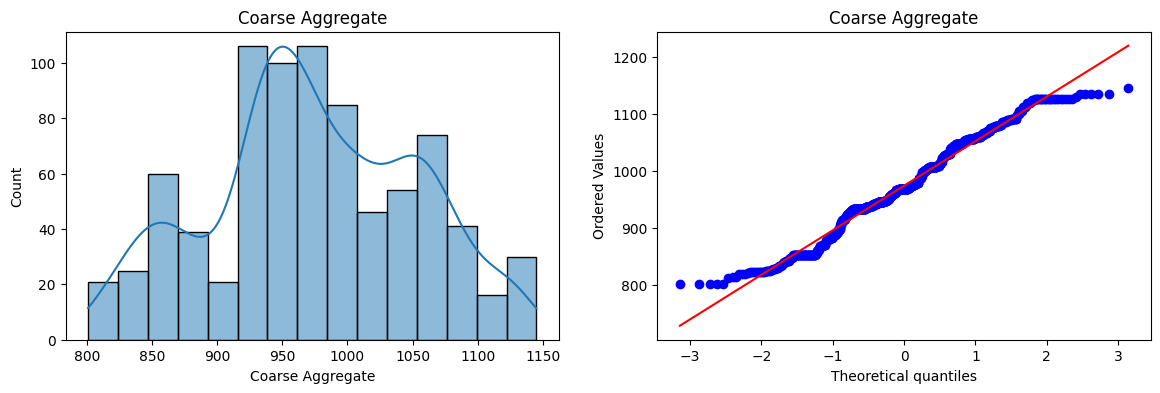

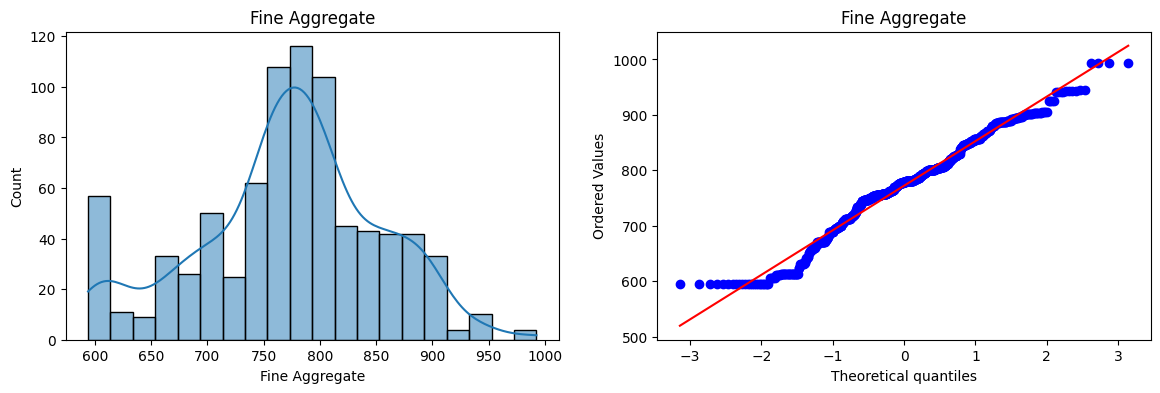

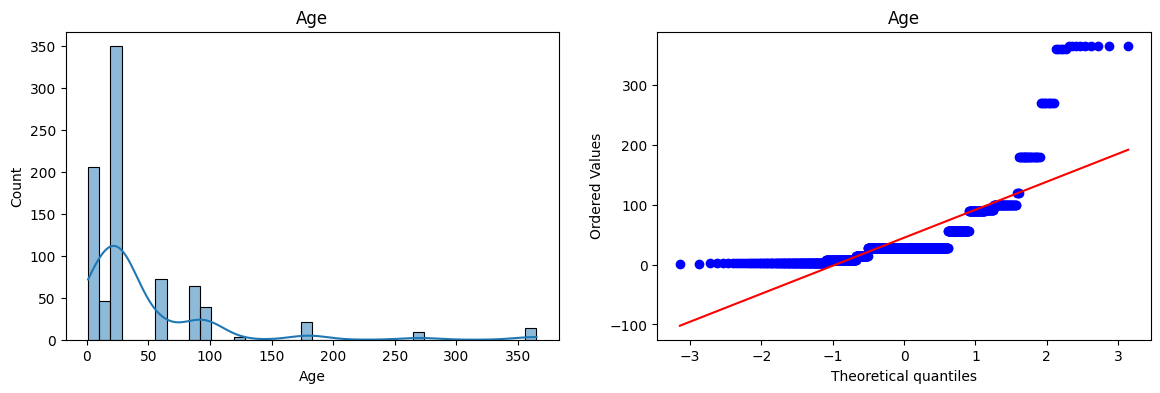

In [121]:
#Plotting the histplot without any transformation

for col in X_train.columns:
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    sns.histplot(X_train[col],kde=True,)
    plt.title(col)

    plt.subplot(122)
    stats.probplot(X_train[col], dist='norm', plot=plt)
    plt.title(col)

    plt.show()
    

In [145]:
#Applying Box-Cox Transform

pt = PowerTransformer(method='box-cox')

X_train_transformed = pt.fit_transform(X_train+0.000001)
X_test_transformed = pt.fit_transform(X_test+0.000001)

pd.DataFrame({'cols':X_train.columns,'box_cox_lambdas':pt.lambdas_})

,cols,box_cox_lambdas
0,Cement,0.215602
1,Blast Furnace Slag,0.025996
2,Fly Ash,-0.006544
3,Water,0.959062
4,Superplasticizer,0.103365
5,Coarse Aggregate,1.192492
6,Fine Aggregate,1.973781
7,Age,-0.014692


In [146]:
#Applying linear Regression on transformed data

lr = LinearRegression()
lr.fit(X_train_transformed, y_train)

y_pred2 = lr.predict(X_test_transformed)
r2_score(y_test, y_pred2)

0.8055321004501623

In [147]:
#Cross validation

pt = PowerTransformer(method='box-cox')
X_transformed = pt.fit_transform(X+0.000001)

lr = LinearRegression()
np.mean(cross_val_score(lr, X_transformed, y, scoring='r2'))

np.float64(0.6662950326831084)

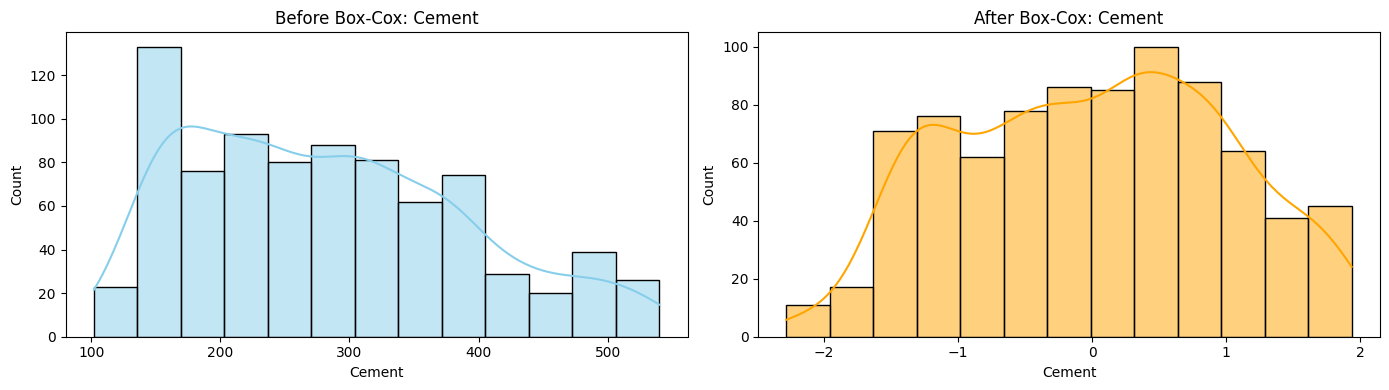

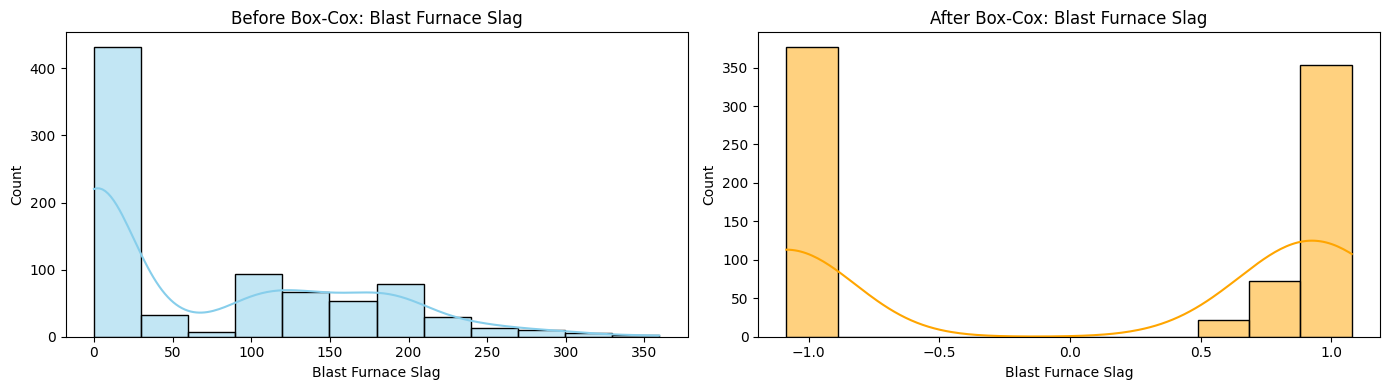

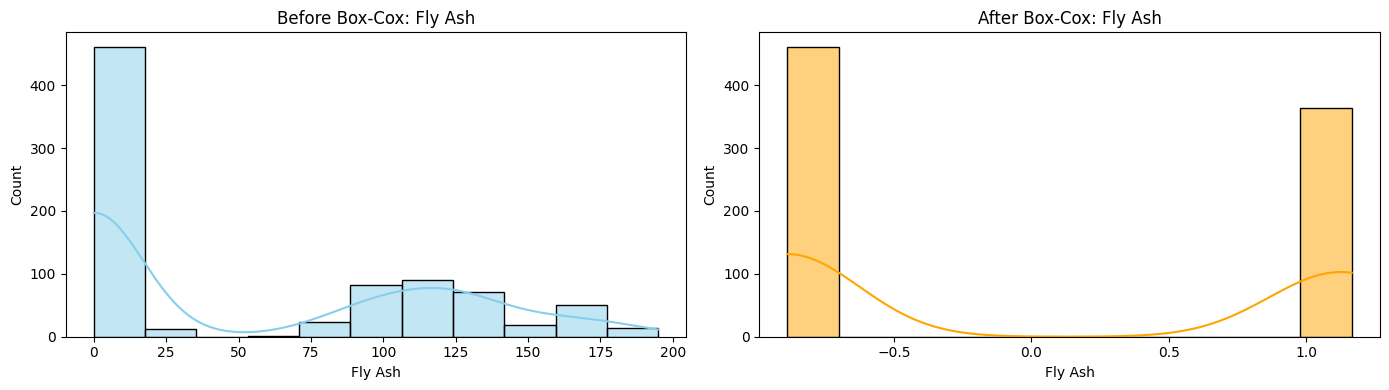

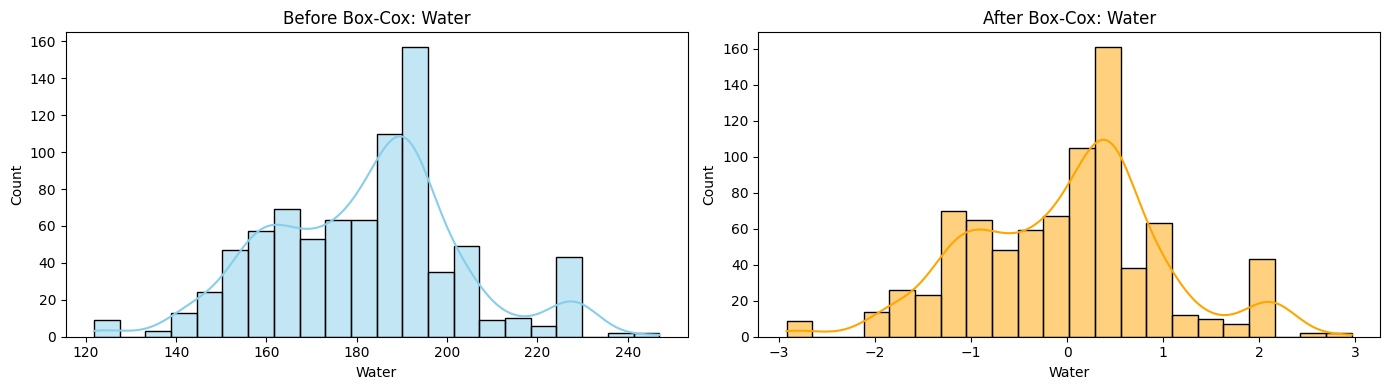

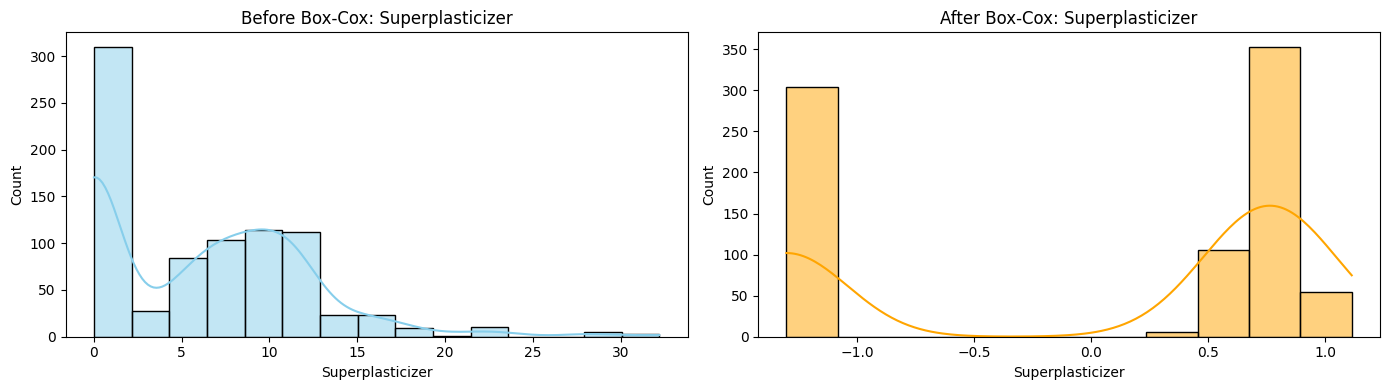

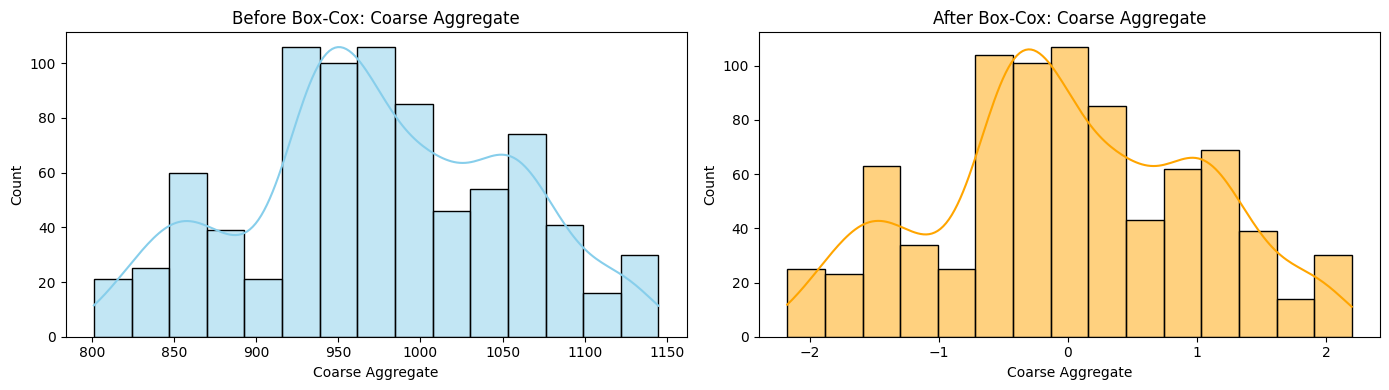

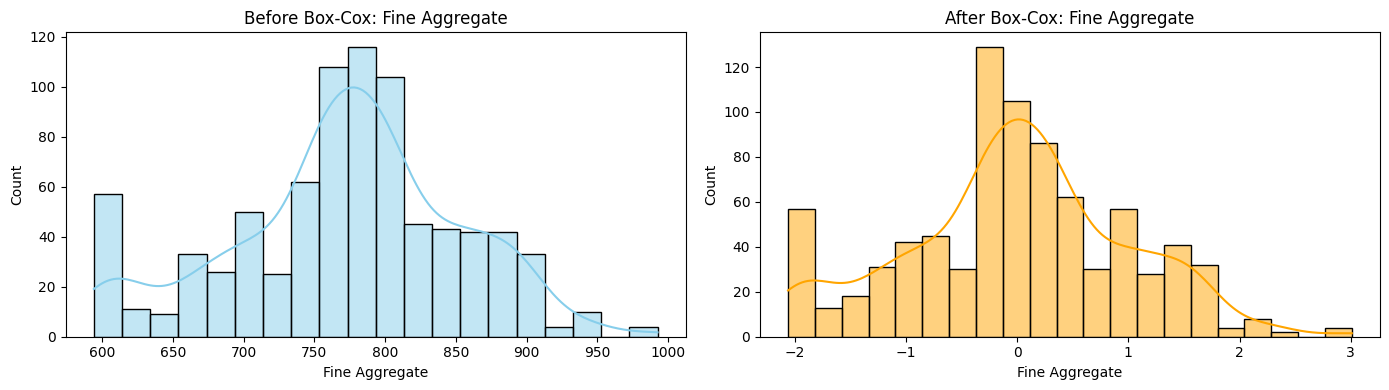

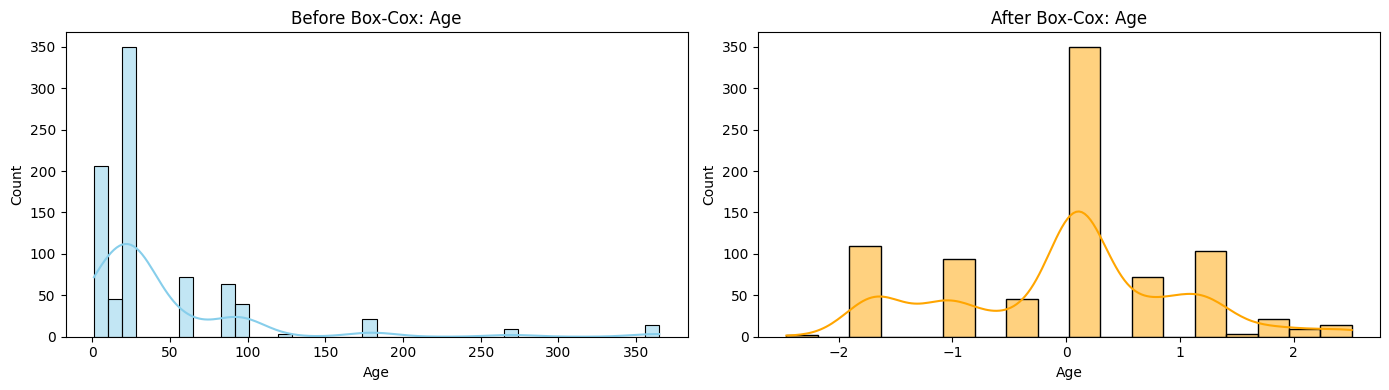

In [148]:
for i, col in enumerate(X_train.columns):

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Before transformation
    sns.histplot(
        X_train[col],
        kde=True,
        ax=axes[0],
        color='skyblue'
    )

    axes[0].set_title(f'Before Box-Cox: {col}')
    axes[0].set_xlabel(col)

    # After transformation
    sns.histplot(
        X_train_transformed[:, i],   # use column index
        kde=True,
        ax=axes[1],
        color='orange'
    )

    axes[1].set_title(f'After Box-Cox: {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

In [149]:
#Apply Yeo_Johnson transform

pt1 = PowerTransformer()

X_train_transformed2 = pt1.fit_transform(X_train+0.000001)
X_test_transformed2 = pt1.fit_transform(X_test+0.000001)

lr = LinearRegression()
lr.fit(X_train_transformed2, y_train)

y_pred3 = lr.predict(X_test_transformed2)
print(r2_score(y_test, y_pred2))

pd.DataFrame({'cols':X_train.columns,
                            'Yeo_Johnson_lambdas':pt1.lambdas_})

0.8055321004501623


,cols,Yeo_Johnson_lambdas
0,Cement,0.213025
1,Blast Furnace Slag,0.020476
2,Fly Ash,-0.038218
3,Water,0.958936
4,Superplasticizer,0.304951
5,Coarse Aggregate,1.192751
6,Fine Aggregate,1.975085
7,Age,-0.062443


In [150]:
#Cross validation

pt1 = PowerTransformer()
X_transformed2 = pt1.fit_transform(X+0.000001)

lr = LinearRegression()
np.mean(cross_val_score(lr, X_transformed2, y, scoring='r2'))

np.float64(0.6834625214390201)

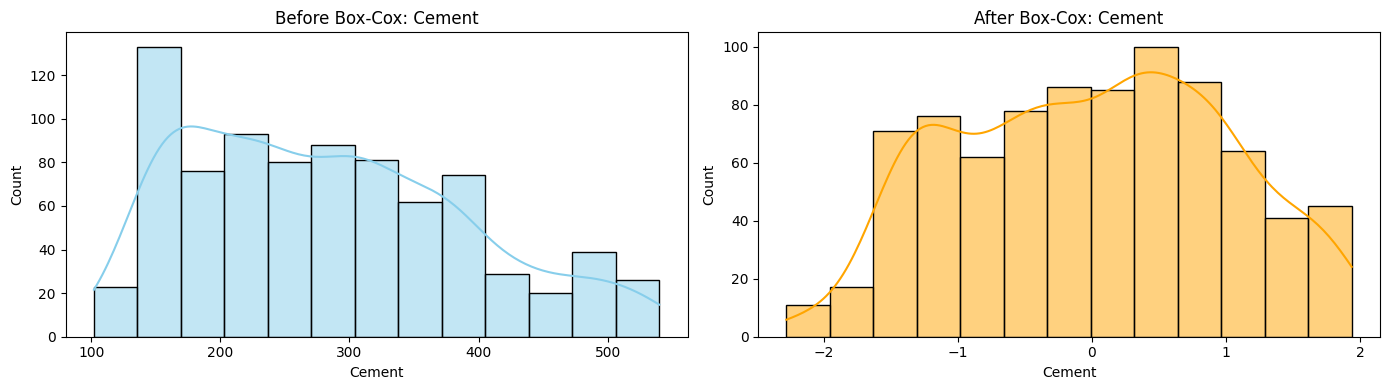

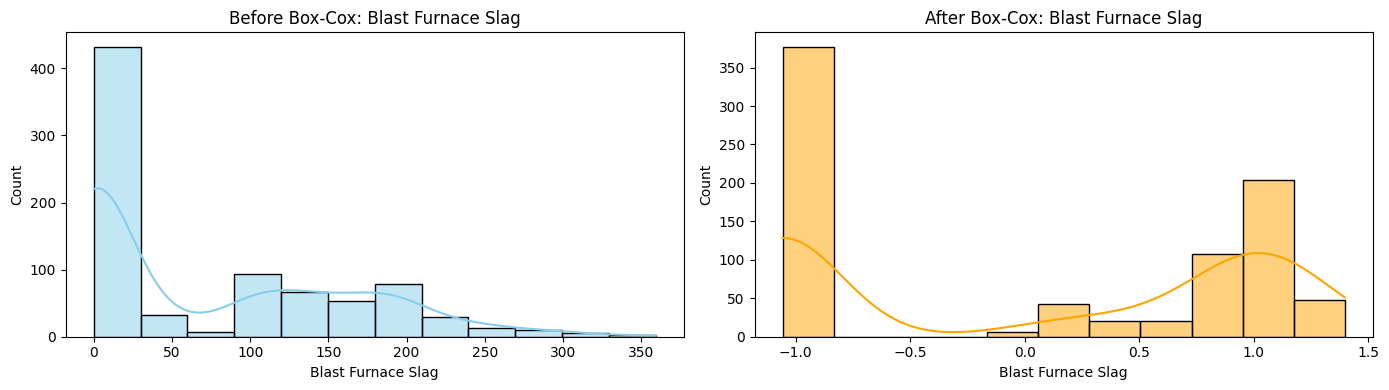

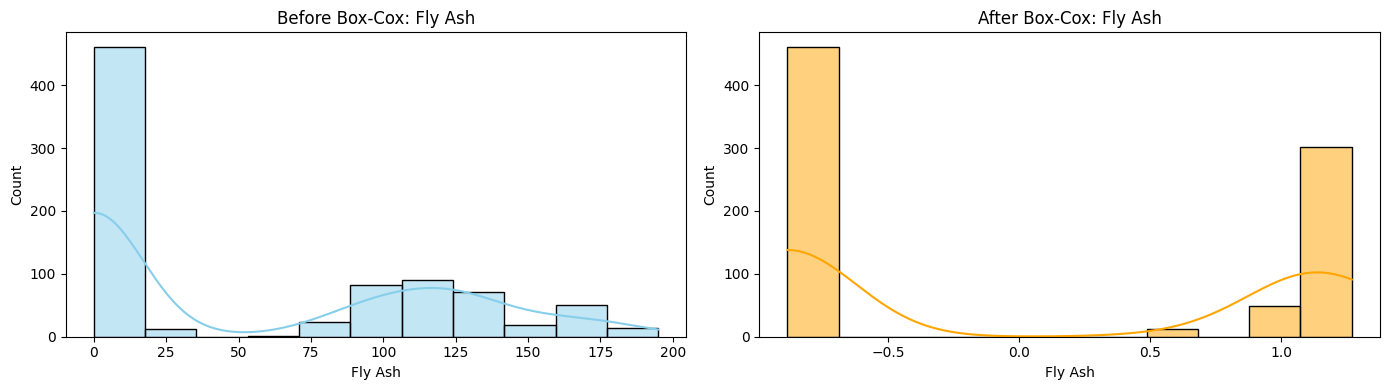

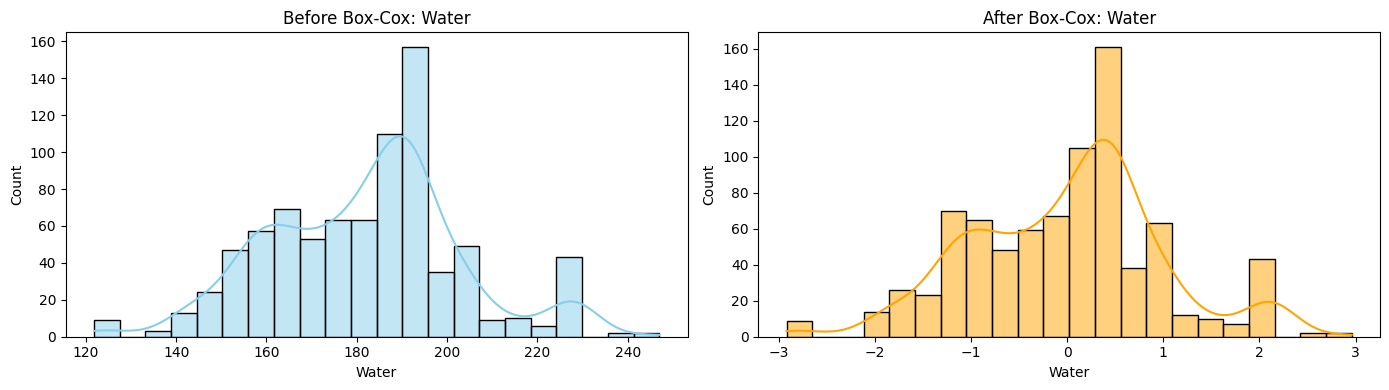

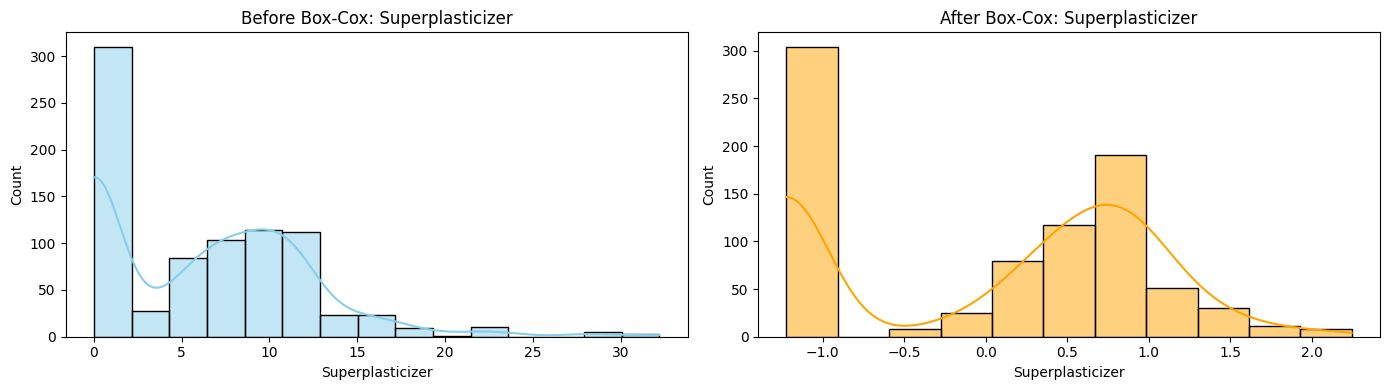

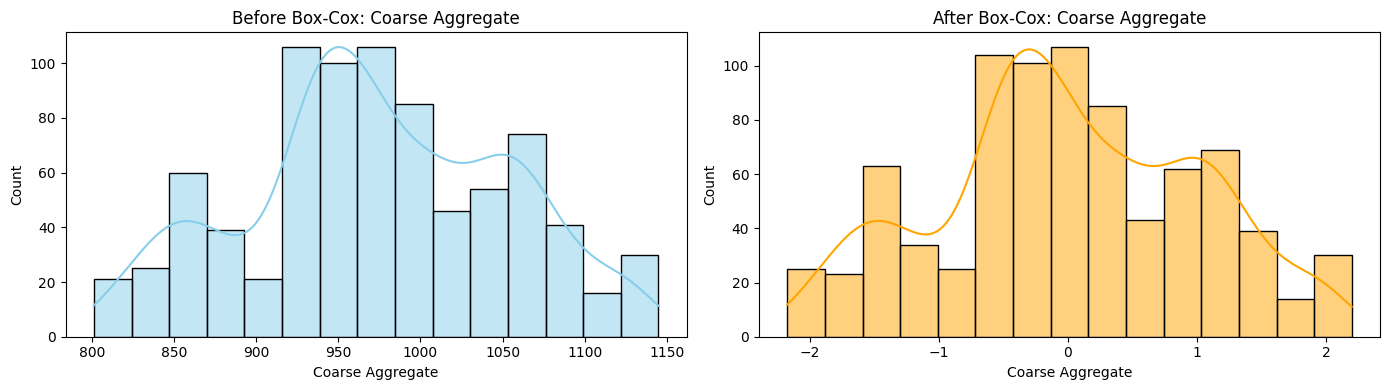

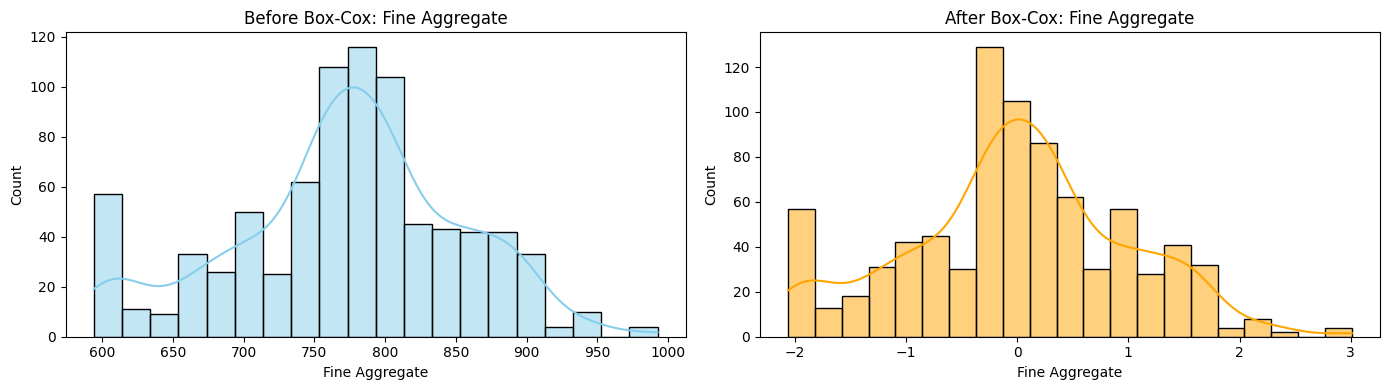

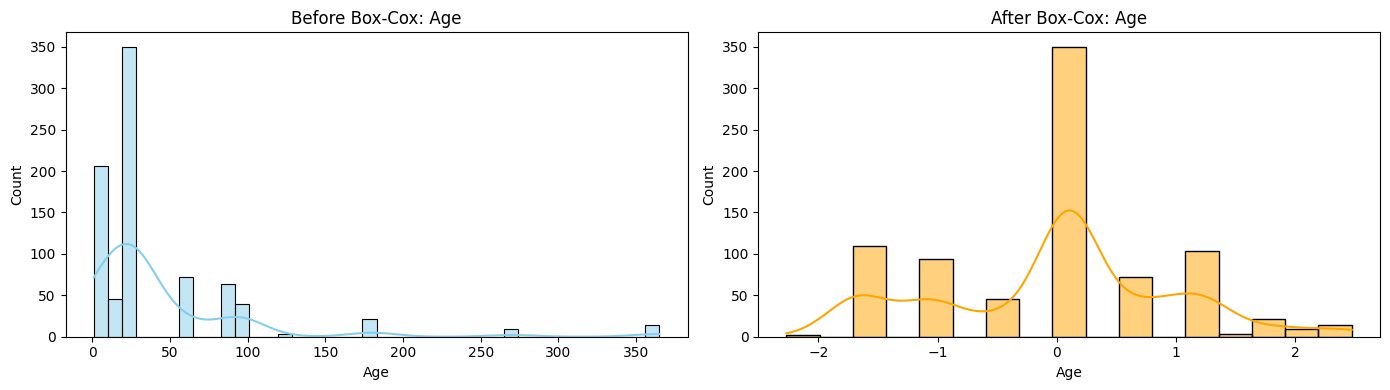

In [151]:
for i, col in enumerate(X_train.columns):

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Before transformation
    sns.histplot(
        X_train[col],
        kde=True,
        ax=axes[0],
        color='skyblue'
    )

    axes[0].set_title(f'Before Box-Cox: {col}')
    axes[0].set_xlabel(col)

    # After transformation
    sns.histplot(
        X_train_transformed2[:, i],   # use column index
        kde=True,
        ax=axes[1],
        color='orange'
    )

    axes[1].set_title(f'After Box-Cox: {col}')
    axes[1].set_xlabel(col)

    plt.tight_layout()
    plt.show()

In [153]:
pd.DataFrame({'cols':X_train.columns, 'box_cox_lambdas':pt.lambdas_, 
              'Yeo_Johnson_lambdas':pt1.lambdas_})

,cols,box_cox_lambdas,Yeo_Johnson_lambdas
0,Cement,0.172271,0.169544
1,Blast Furnace Slag,0.025273,0.016633
2,Fly Ash,-0.032412,-0.136480
3,Water,0.809568,0.808438
4,Superplasticizer,0.099711,0.264160
5,Coarse Aggregate,1.129168,1.129395
6,Fine Aggregate,1.829625,1.830763
7,Age,0.048975,0.001771
